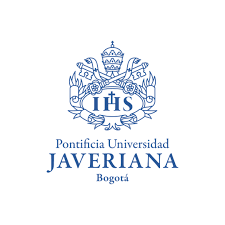
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Modelo de clasificacion - PySpark**

## Repositorio: https://github.com/jcamilo-gaitan/Taller-de-clasificacion---Apache-Spark

Autor: Julián Camilo Gaitán Contreras


Fecha actual: 28/04/2026

Este es un ejercicio en el cual se ralizará entendimiento de  datos, limpieza de datos, se evaluarán transformaciones y se intentará hacer una aproximación a la realidad mediante la creación de un modelo de aprendizaje de máquina. Aquí la variable objetivo será y : ¿ el cliente **suscribirá un depósito a plazo**  ?

# Importar bibliotecas generales

In [1]:
# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import pandas as pd # IMPORTANTE *NO* PASAR OBJETOS SPARK A  PANDAS , SOLO SE DEBE USAR PANDAS PARA OBJETOS PEQUEÑOS
import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

In [2]:




## BIBLIOTECAS ESPECIALIZADAS DE SPARK - - - - - - - - - - - - - - - - - - - -



import findspark

findspark.init('/Almacen/Spark')

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc
from pyspark.ml import Pipeline

# Levantamiento de sesión spark

In [3]:
### Levantamiento de sesión SPARK
configura = SparkConf()

configura.setAppName("lab28/ABR_Gaitan")

sparkGaitan = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkGaitan.sparkContext, sparkSession=sparkGaitan)

sparkContextoS = sparkGaitan.sparkContext.getOrCreate()

print("Sesion creada: SparkGaitan")
sparkGaitan

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 10:45:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/24 10:45:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Sesion creada: SparkGaitan


# Lectura de los datos y entendimiento del negocio.

In [4]:
datos=sparkGaitan.read.format("csv").option("header","true").option("sep",";").load("bank-full.csv")
datos.show(5) # La variable objetivo es y 

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

In [5]:
# La variable objetivo es y (PAGA O NO PAGA) 

In [6]:
print("registros: ",datos.count())

[Stage 2:=============================>                             (1 + 1) / 2]

registros:  45211


In [7]:
datos.printSchema() #  Quedaron bien

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## 📊 Dataset: Bank Marketing (UCI)

Este dataset corresponde a campañas de marketing telefónico de un banco portugués.  
El objetivo es predecir si un cliente **suscribirá un depósito a plazo** (`y`). :contentReference[oaicite:1]{index=1}

---

### 🧾 Tabla de Variables

| Variable   | Tipo        | Descripción                                                                 |
|------------|------------|-----------------------------------------------------------------------------|
| age        | Numérico    | Edad del cliente.                                                           |
| job        | Categórico  | Tipo de trabajo (admin, técnico, estudiante, desempleado, etc.).           |
| marital    | Categórico  | Estado civil (soltero, casado, divorciado).                                |
| education  | Categórico  | Nivel educativo (primaria, secundaria, universidad, etc.).                 |
| default    | Binario     | Indica si tiene crédito en incumplimiento (`yes` / `no`).                  |
| balance    | Numérico    | Balance promedio anual en euros.                                           |
| housing    | Binario     | Tiene préstamo hipotecario (`yes` / `no`).                                 |
| loan       | Binario     | Tiene préstamo personal (`yes` / `no`).                                    |
| contact    | Categórico  | Tipo de contacto (teléfono fijo o celular).                                |
| day        | Numérico    | Día del mes del último contacto.                                           |
| month      | Categórico  | Mes del último contacto.                                                   |
| duration   | Numérico    | Duración de la última llamada (segundos). ⚠️ Puede sesgar el modelo.       |
| campaign   | Numérico    | Número de contactos en esta campaña.                                       |
| pdays      | Numérico    | Días desde el último contacto anterior (-1 = nunca contactado).            |
| previous   | Numérico    | Número de contactos previos.                                               |
| poutcome   | Categórico  | Resultado de la campaña anterior (éxito, fracaso, etc.).                   |
| y          | Binario     | 🎯 Variable objetivo: ¿suscribió el depósito? (`yes` / `no`).              |

---

### Aspectos a tener en cuenta

- La variable `duration` **no se usará para construir el modelo**, pues se requiere predecir si un cliente contratará un deposito antes de preguntarle. :contentReference[oaicite:2]{index=2}  
- El dataset contiene **más de 45,000 registros** se abordará el problema de **clasificación binaria**. :contentReference[oaicite:3]{index=3}  
- Existe **desbalance de clases** (muchos más "no" que "sí"). :contentReference[oaicite:4]{index=4}  

---

### Objetivo del modelo

Predecir:  

**¿El cliente contratará un depósito a plazo?**

# Exploracion de datos

In [8]:
from pyspark.sql.functions import col, isnan, when, count

datos.select([
    count(
        when(isnan(col(c)) | col(c).isNull(), c)
    ).alias(c)
    for c in datos.columns
]).show()

[Stage 5:=============================>                             (1 + 1) / 2]

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



No existen valores faltantes en el conjunto de datos.

In [9]:
# Cambio de columnas a enteros
from pyspark.sql.functions import col
enteras= ["balance","age","day","duration","campaign","pdays","previous"]


for c in enteras:
    datos = datos.withColumn(c, col(c).cast("int"))
datos.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



- Todos los datos estan en string
- Es necesario hacer cambio de tipos de datos

In [10]:

#Balance del conjunto de datos para la variable y

datos.groupBy(["y"]).count().show()

# Existe desbalance de clases 

[Stage 8:=============================>                             (1 + 1) / 2]

+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+



- Existe desbalance de clases, esto puede afectar el entrenamiento del modelo, haciendolo mas confiable para una clase que la otra. Se puede introducir un posible sesgo hacia la clase "yes".
- La proporción es 89% vs 11%.
- Es posible que se requiera hacer un remuestreo para la clase "yes".

In [11]:
## Revisión de estadísticas
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

numericas = [
    f.name for f in datos.schema.fields 
    if isinstance(f.dataType, (IntegerType, DoubleType, FloatType, LongType))
]

for columna in numericas:
    print(f"Resumen de {columna}")
    datos.describe([columna]).show()

Resumen de age


+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             45211|
|   mean| 40.93621021432837|
| stddev|10.618762040975401|
|    min|                18|
|    max|                95|
+-------+------------------+

Resumen de balance
+-------+------------------+
|summary|           balance|
+-------+------------------+
|  count|             45211|
|   mean|1362.2720576850766|
| stddev|3044.7658291685243|
|    min|             -8019|
|    max|            102127|
+-------+------------------+

Resumen de day
+-------+-----------------+
|summary|              day|
+-------+-----------------+
|  count|            45211|
|   mean|15.80641879188693|
| stddev|8.322476153044589|
|    min|                1|
|    max|               31|
+-------+-----------------+

Resumen de duration
+-------+-----------------+
|summary|         duration|
+-------+-----------------+
|  count|            45211|
|   mean|258.1630797814691|
| stddev|257.5278122651712|
|

## Comentarios (numericas)
- Edad:(explicar)  
  el rango va entre 18 y 95 anos, promedio en 45.
- Trabajo:  
  Administrador es la que menos está presente, Unknown es lo mas repetido.
- Duration:
  Promedio de 258 segundos y desv de 257, existe bastante dispersión, la media no es confiable para generalizar a todos los valores de esta variable.
- Balance:  
  Promedio de 1362 euros
  (explicar)
- Contact:  
  Promedio de 2.76
  (explicar)
- pdays:  
      :)
  
  
      **IMPORTANTE:** cuando esta variable toma el valor (-1), significa que el cliente nunca ha sido contactado

  


Para tener en cuenta, obsérvese la cantidad de registros que tienen este valor :


In [12]:
from pyspark.sql.functions import col
# ¿Cuantas personas en el conjunto de datos no se les ha contactado previamente?
# Contar registros donde pdays == -1
cantidad = datos.filter(col("pdays") == -1).count()
porcentaje=cantidad/ datos.count()
print(f"Cantidad de personas con pdays = -1: {cantidad}")
print(f"Porcentaje pdays = -1: {porcentaje}")



Cantidad de personas con pdays = -1: 36954
Porcentaje pdays = -1: 0.8173674548229414


El 81% de todos las personas registradas no han sido contactadas.Este será un factor a tener en cuenta.

A continuación se muestran los histogramasm que nos permitiránb entender el comportamiento generalizado de las variables numéricas.

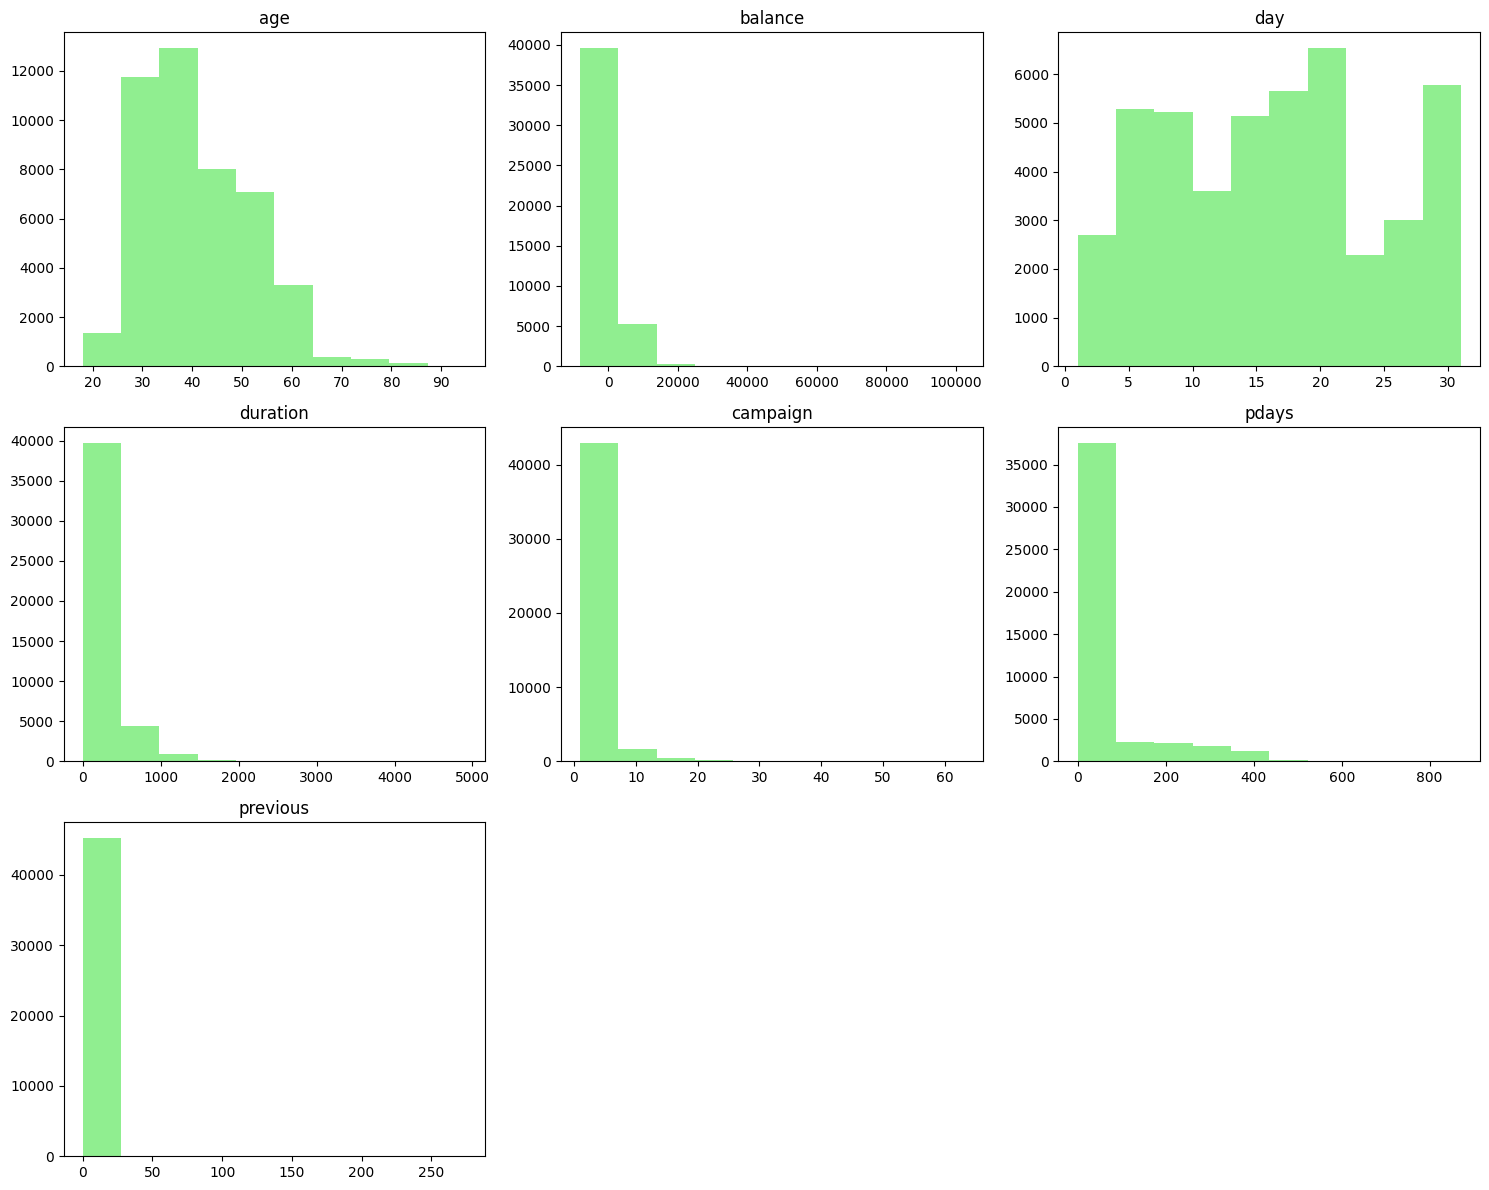

In [13]:
import matplotlib.pyplot as plt
import math

# Número de columnas de la matriz
ncols = 3

# Número de filas necesarias
nrows = math.ceil(len(numericas) / ncols)

# Crear figura y ejes
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

# Convertir axes en arreglo plano
axes = axes.flatten()

# Crear histogramas
for i, col in enumerate(numericas):
    
    histico = datos.select(col).toPandas()
    
    axes[i].hist(histico[col], bins=10, color='lightgreen')
    axes[i].set_title(col)

# Eliminar gráficos vacíos si sobran espacios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A continuación se muestran los diagramas boxplots que permitiran entender más las distribuciones de las variables numéricas detectando datos atipicos mediante la observación de los cuartiles.

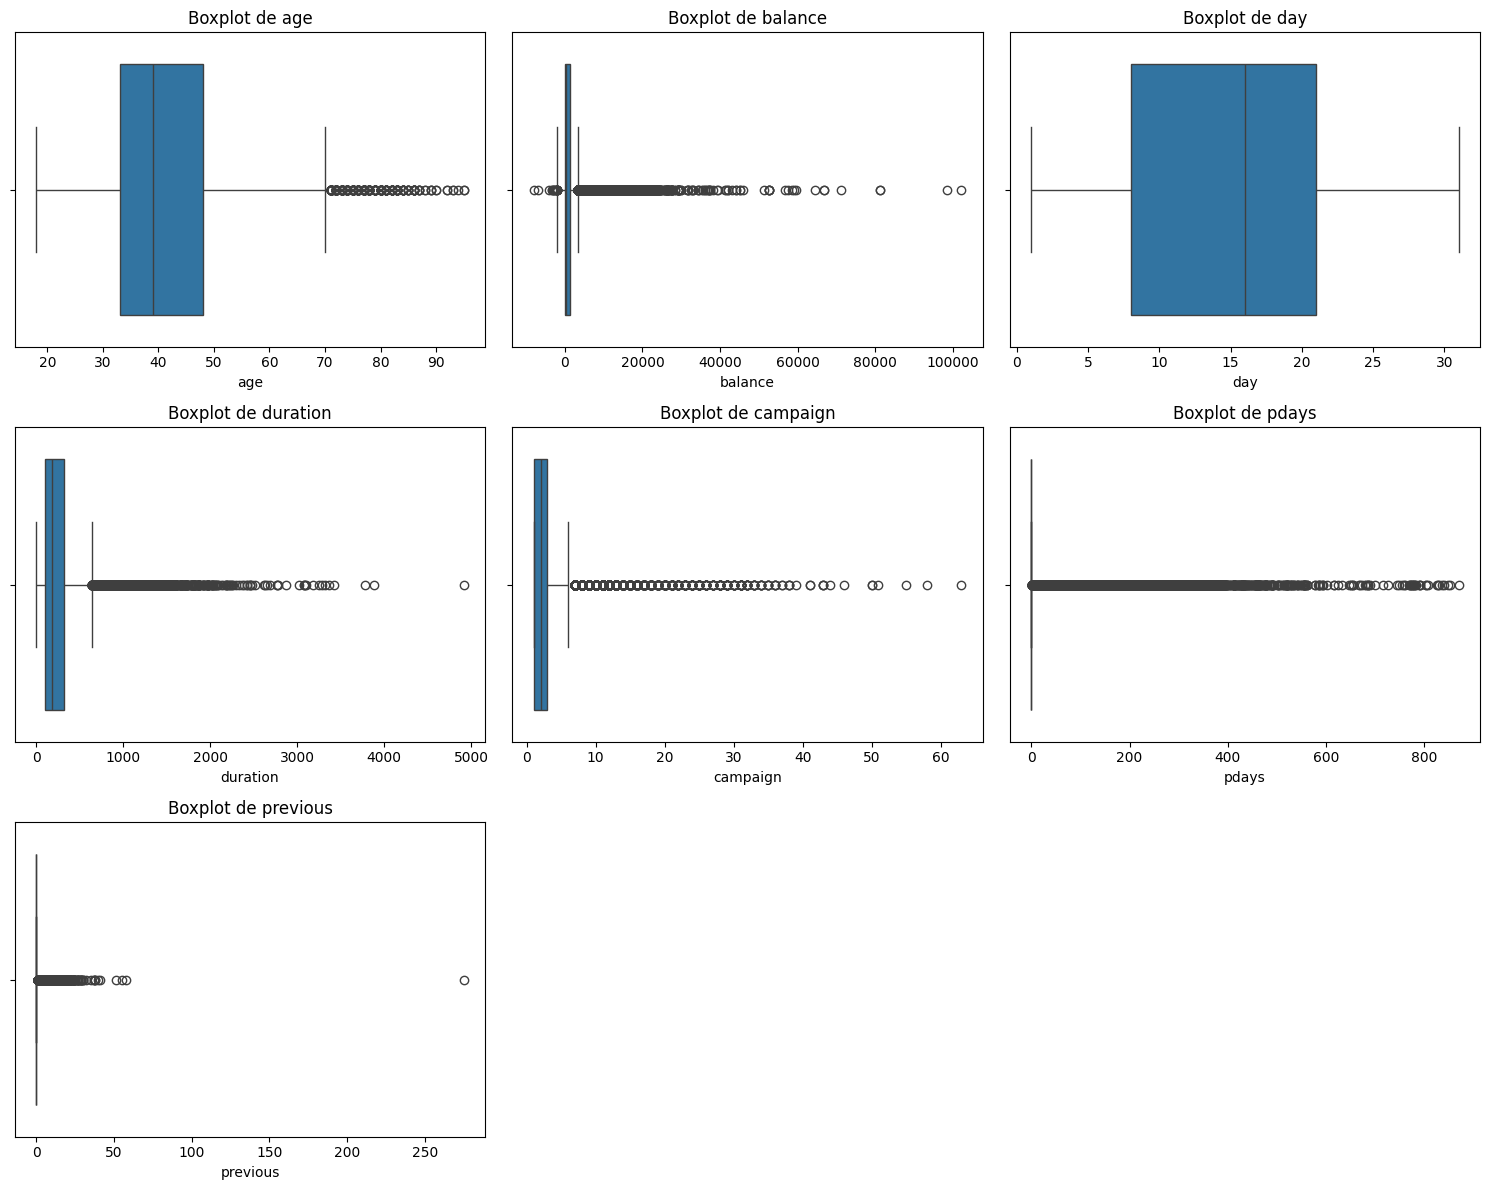

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Convertir columnas numéricas a pandas
pdf = datos.select(numericas).toPandas()

# Configuración de la matriz
ncols = 3
nrows = math.ceil(len(numericas) / ncols)

# Crear figura y ejes
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

# Aplanar ejes para recorrer fácilmente
axes = axes.flatten()

# Crear boxplots
for i, col in enumerate(numericas):
    sns.boxplot(
        x=pdf[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot de {col}")

# Eliminar espacios vacíos sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

-  Las distribuciones previous, pdays, balance, duration , campaign tienen bastantes datos concentrados en valores muy pequeños, lo que permite que el RIQ sea pequeño y por ende existan muchos valores atípicos.
  
-  Hay varias ditribuciones sesgadas hacia la izquierda, es decir, altas concentraciones en valores pequeños de las variables. Esto pude estar ocasionando el comportamiento observado en estos gráficos

-  Se observa que la variable balance (dinero en el banco) esta bastante sesgada , con gran concentración en un pequeño intervalo pero con bastantes registros atípicos que tienen más dinero de lo común (Básandose en el rango intercuartílico).

-  Se observa que la variable campaign (Numeroc de contactos realizados en la campaña) esta bastante sesgada , con gran concentración en un pequeño intervalo. Entonces gran parte de las campañas tienen pocos contactos, pero cuando hay más contactos que en el promedio de los casos, la diferencia es significativa.
-  DAY, es la unica distribución sin atípicos, razonablemente. Pues representa el dia del mes, hacer un análsis numérico de esta variable es contradictorio con su naturaleza categórica a pesar de representarse como un número




## Matriz de correlación.

Se pinta la matriz de correlación para las variables numéricas con el fin de detectar variables independientes corelacionadas.

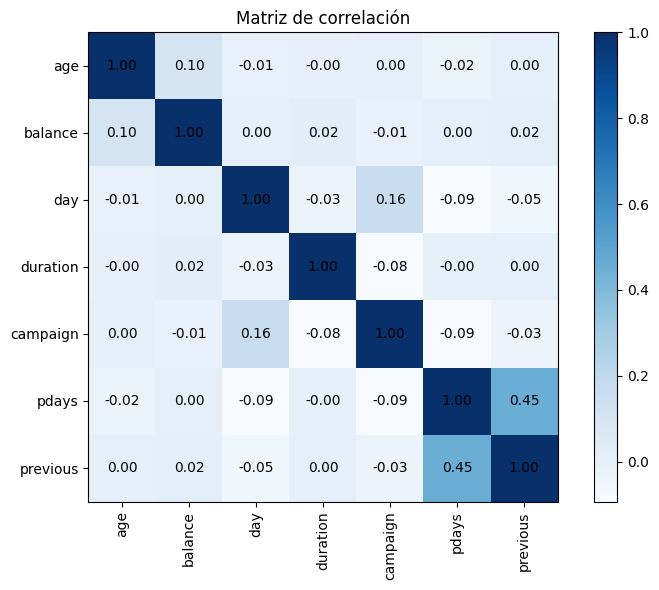

In [15]:
import matplotlib.pyplot as plt
import numpy as np
## Matriz de correlación 
from pyspark.ml.feature import VectorAssembler 
from pyspark.ml.stat import Correlation 
# crear vector de features 
assemblerNum = VectorAssembler( inputCols=numericas, outputCol="features" ) 
df_vector = assemblerNum.transform(datos).select("features") 
# calcular correlación 
corr_matrix = Correlation.corr(df_vector, "features", "pearson").collect()[0][0] 
# convertir a array 
corr_array = corr_matrix.toArray() 
import pandas as pd 
corr_df = pd.DataFrame( corr_array, index=numericas, columns=numericas )
plt.figure(figsize=(8,6))

# Mostrar matriz
plt.imshow(corr_df, cmap='Blues')

# Agregar barra de color
plt.colorbar()

# Etiquetas de ejes
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)

# Agregar valores dentro de cada celda
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j, i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black'
        )

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

No existen correlaciones significativas para las variables numéricas.
- Solamente sobresale la correlación entre 'pdays' y 'previous' , es decir, si los contactos previos al sujeto suben, los días desde el último contacto también sube (Logicamente).
- En general, no existen correlaciones significativas entre las variables numéricas.

### Distribución de las variables categóricas

Se listarán las distribuciones de valores correspondientes a cada variable categórica del conjunto de datos y se pintarán.

In [16]:

# Observar las distribuciones de las variables categoricas
from pyspark.sql.types import StringType, BooleanType

categoricas = [ # Se extraen las columnas categoricas 
    f.name for f in datos.schema.fields
    if isinstance(f.dataType, (StringType, BooleanType))
]
from pyspark.sql import functions as F

total = datos.count() # Extrar total de registros para extraer porcentajes

for col in categoricas:  # para todas las columnas, agrupamos por cada categoria, reflejamos cantidad de registros y porcentaje correspondiente
    print(f"Distribución de {col}")
    datos.groupBy(col).count().withColumn("porcentaje", F.col("count") / total * 100).orderBy(F.desc("count")).show()  # Ordenar las "agrupaciones".show()

Distribución de job
+-------------+-----+------------------+
|          job|count|        porcentaje|
+-------------+-----+------------------+
|  blue-collar| 9732|21.525734887527374|
|   management| 9458|20.919687686624936|
|   technician| 7597| 16.80343279290438|
|       admin.| 5171|11.437482028709828|
|     services| 4154| 9.188029461856628|
|      retired| 2264|5.0076308862887355|
|self-employed| 1579|3.4925128840326467|
| entrepreneur| 1487| 3.289022582999712|
|   unemployed| 1303|2.8820419809338436|
|    housemaid| 1240|2.7426953617482472|
|      student|  938| 2.074716330096658|
|      unknown|  288|0.6370131162770122|
+-------------+-----+------------------+

Distribución de marital
+--------+-----+------------------+
| marital|count|        porcentaje|
+--------+-----+------------------+
| married|27214|60.193315785981284|
|  single|12790| 28.28957554577426|
|divorced| 5207|11.517108668244454|
+--------+-----+------------------+

Distribución de education
+---------+-----+---

Se puede observar estas distribuciónes de forma gráfica.


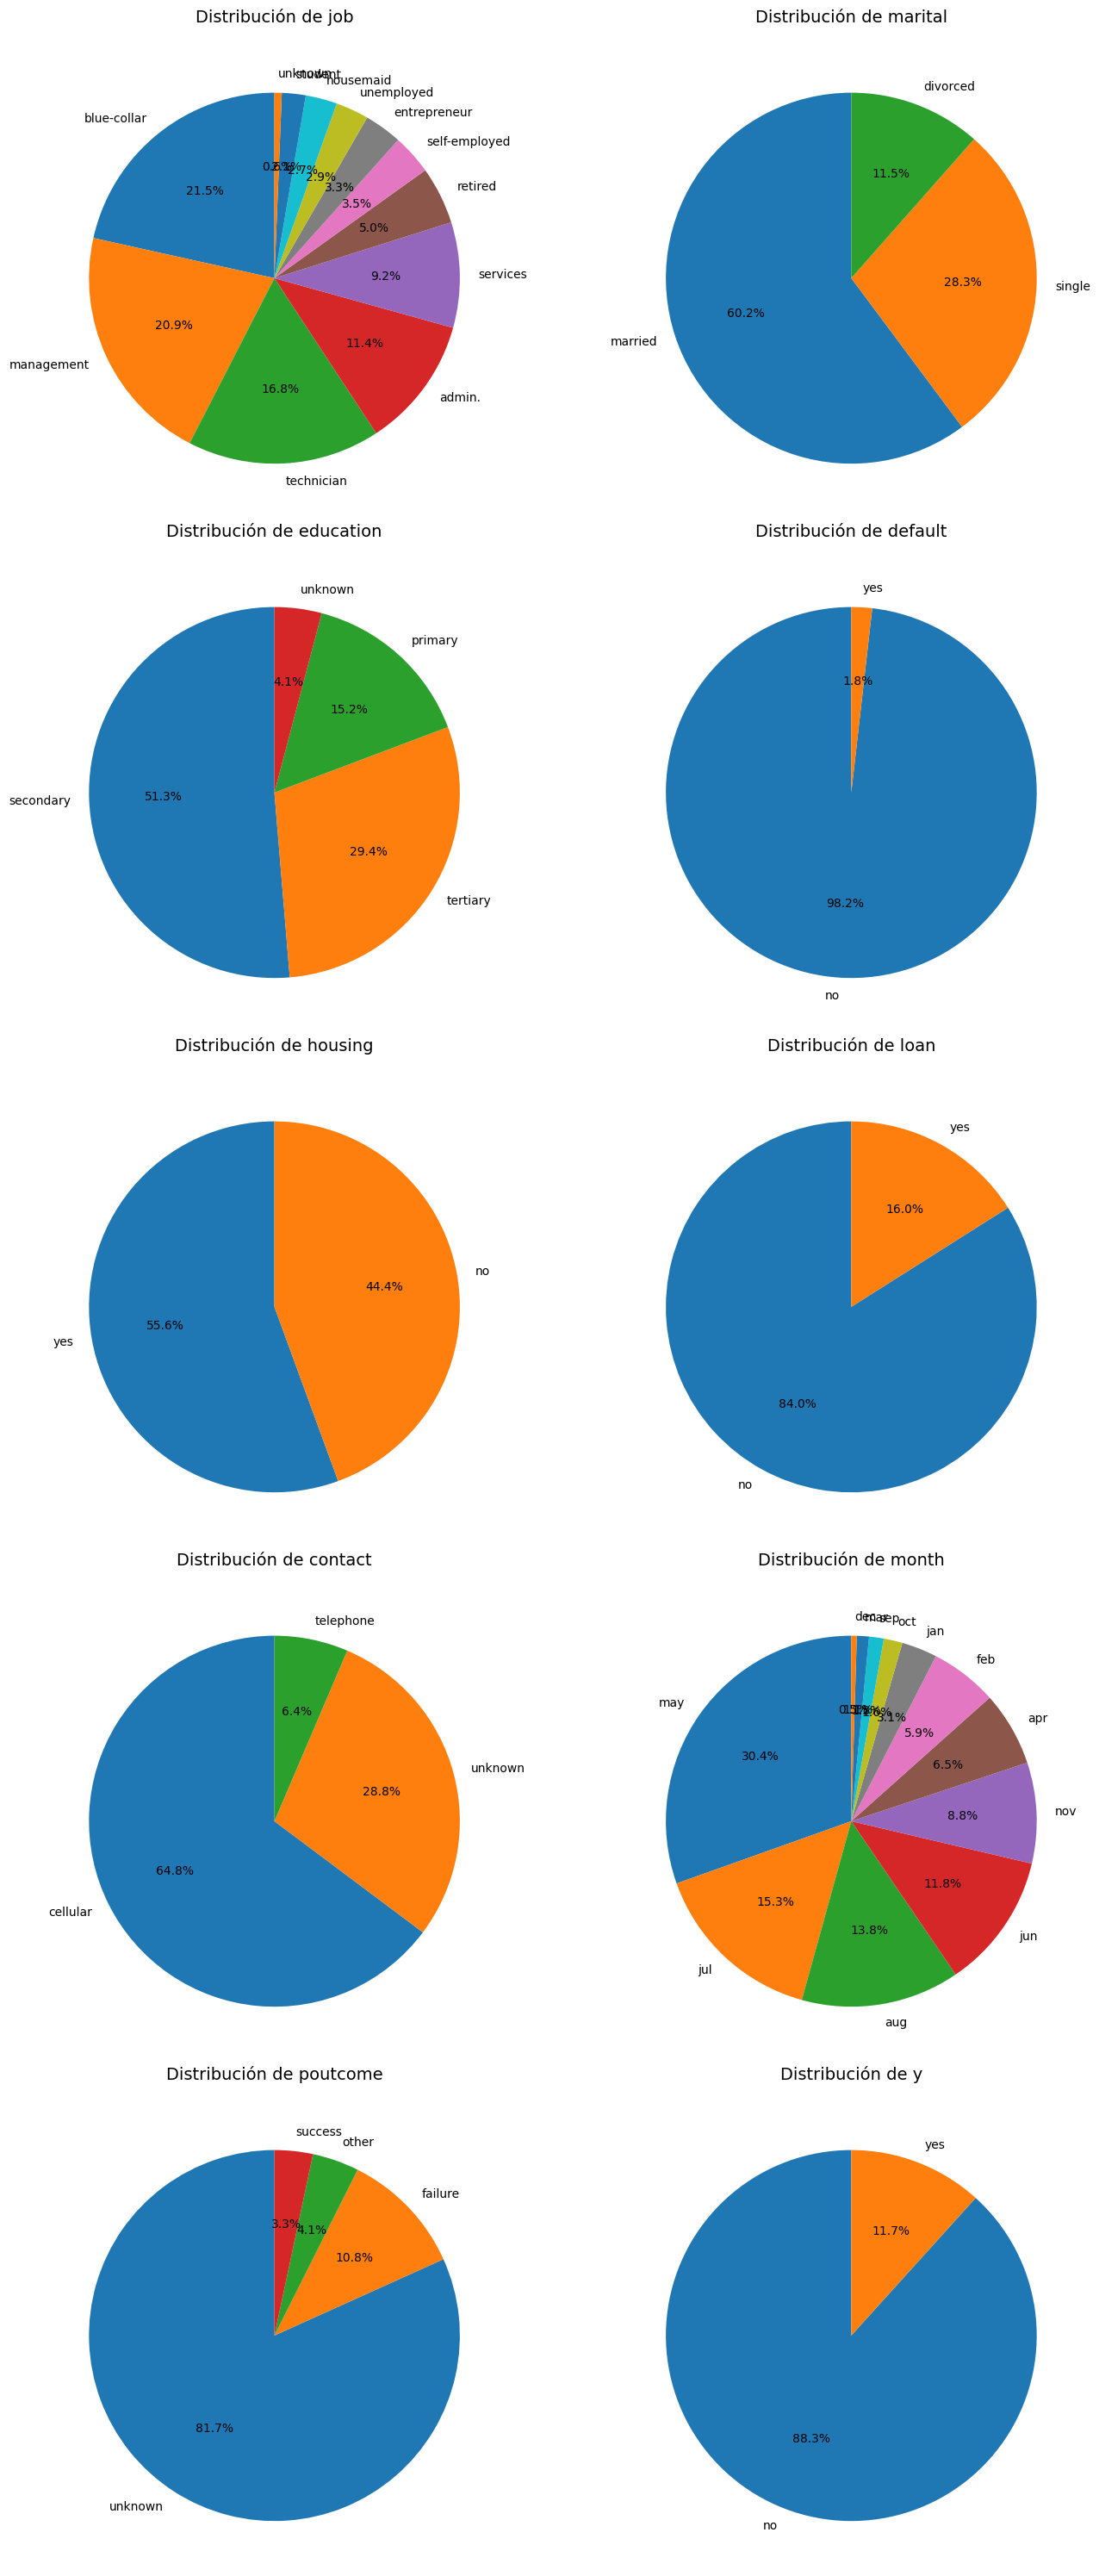

In [17]:
import matplotlib.pyplot as plt
import math
from pyspark.sql import functions as F

# Número de columnas de la matriz
ncols = 2
nrows = math.ceil(len(categoricas) / ncols)

# Crear figura
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 6 * nrows)
)

# Aplanar ejes
axes = axes.flatten()

# Total de registros
total = datos.count()

# Crear gráficos
for i, col in enumerate(categoricas):

    # Obtener datos agrupados
    temp = (
        datos.groupBy(col)
        .count()
        .withColumn(
            "porcentaje",
            F.col("count") / total * 100
        )
        .orderBy(F.desc("count"))
        .toPandas()
    )

    # Graficar torta
    axes[i].pie(
        temp["count"],
        labels=temp[col],
        autopct='%1.1f%%',
        startangle=90
    )

    # Título grande y separado
    axes[i].set_title(
        f"Distribución de {col}",
        fontsize=14,
        pad=20
    )

# Eliminar espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Comentarios (discretas)

-  Poutcome:
    
   Unknown el más repetido, mayormente se desconoce esta característica.

- Married:
    
   Mayoria de los que compran depositos estan casados (en el conjunto de datos)

- Month:

    Mayoría en mayo y pocos en diciembre, razonable dada la cultura de la sociedad de la muestra del conjunto de datos

- Default:

  La mayoria de personas registradas ( aprox. 98%) no tiene creditos incumplidos, menos del 2% es incumplido en sus pagos.

  
- Education:

      Un poco más de la mitad de las personas tiene educación hasta el grado secundario, le sigue educación terciaria con 27%, como detalle importante, no se conoce el dato del 4 % de las personas.


- Job:

  Aunque la mayoría de las personas hacen trabajos manueales, existe una distribución diversa de los trabajos en los registros del conjunto de datos. Afortunadamente, sólamente el 0.63% tiene un trabajo desconocido.

      

- y (Compra o no Compra):

   Como previamente se habia detallado, existe desbalance notable de clase, la clase mayoritaria es "no".
  

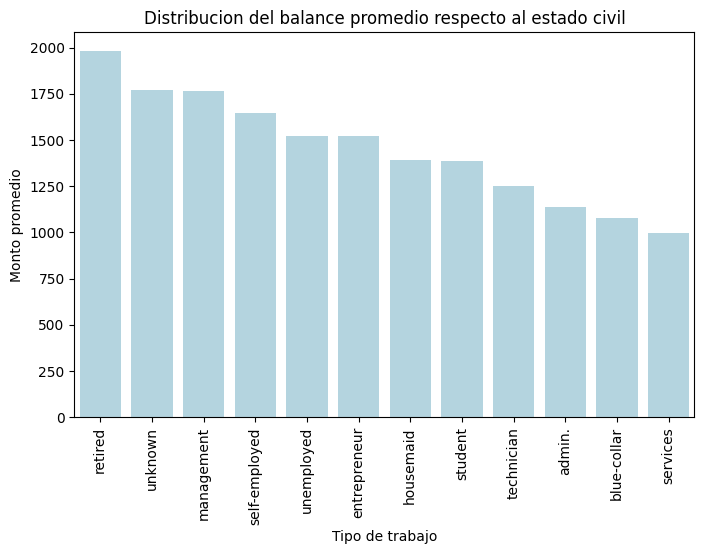

In [18]:
# Valores promedio de balance respecto al tipo de trabajo.
monto_trabajo=datos.groupBy('job').agg({'balance':'mean'}).toPandas()
monto_trabajo=monto_trabajo.sort_values('avg(balance)',ascending=False)
plt.figure(figsize=(8,5))
plt.title("Distribucion del balance promedio respecto al estado civil")
sns.barplot(data=monto_trabajo,x='job',y='avg(balance)',color='lightblue')
plt.xlabel("Tipo de trabajo")
plt.ylabel("Monto promedio")
plt.xticks(rotation=90)
plt.show()

Se observa que en promedio, las personas retiradas ,adminstradores y de las que no se conoce su profesión tiene mayor balance en general. En contraste los que trabajan en servicios y en trabajos manuales ostentan un menor balance promedio

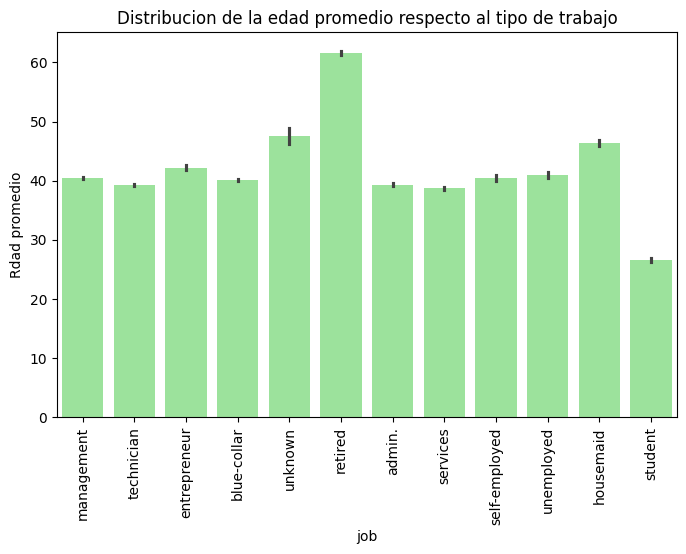

In [19]:
#Edad vs tipo de trabajo

datos1=datos.toPandas()
monto=datos.groupBy('job')

plt.figure(figsize=(8,5))
plt.title("Distribucion de la edad promedio respecto al tipo de trabajo")
sns.barplot(data=datos1,x='job',y='age',color='lightgreen')
plt.ylabel("Rdad promedio")
plt.xticks(rotation=90)
plt.show()

Logicamente, las personas retiradas tienen mayor edad promedio que las demás clases, así como los estudiantes tienen la menor edad promedio.

Respecto a las demás clases, se observa uniformidad en los valores promedio de edad.

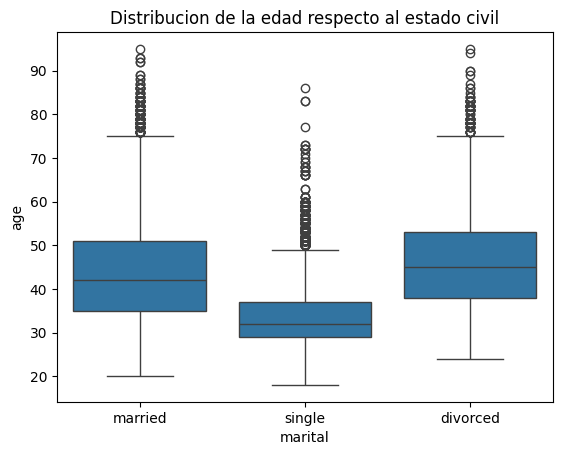

In [20]:
#Edad vs estadocivil boxplot}
plt.figure()
plt.title("Distribucion de la edad respecto al estado civil")
sns.boxplot(x='marital', y='age', data=datos1)
plt.show()



Se puede observar un  fenomeno de la vida real: las personas más jóvenes tienden a estar solteras, mientras que cuando la edad aumenta las personas ya se han casado o divorciado.
Si se observa la distribución de la edad en el valor 'single' se puede notar que existen valores extremos, consecuentemente es "extraño" encontrar personas solteras en mayores edades


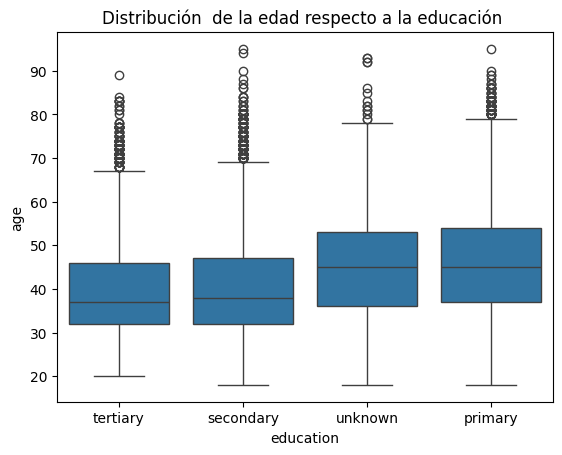

In [21]:
# Edad vs tipoeducacion
plt.figure()
plt.title("Distribución  de la edad respecto a la educación ")
sns.boxplot(x='education', y='age', data=datos1)
plt.show()

Se observa uniformidad en la distribución de la edad respecto al tiño de educación, si bien existen diferencias entre cuartiles, no son significativas.

## Variables numéricas respecto a la variable objetivo 

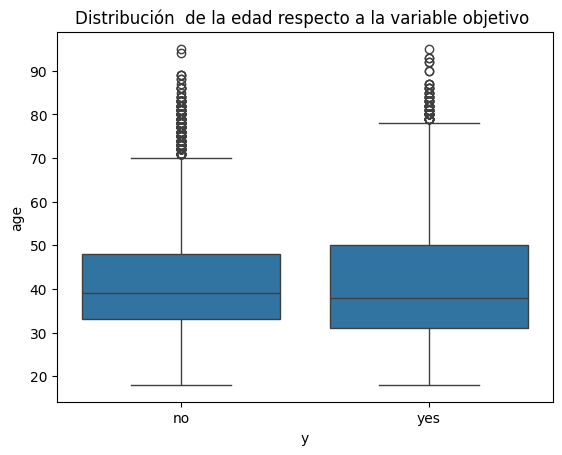

In [22]:
# Edad vs y
plt.figure()
plt.title("Distribución  de la edad respecto a la variable objetivo ")
sns.boxplot(x='y', y='age', data=datos1)
plt.show()

Se observa que Q3 y Q1 para 'yes' son mas amplios entre sí que en el caso 'no' ligeramente, esto podría sugerir que personas con más edad podrían tener una leve tendencia a estar interesadas en suscribir depsositos a largo plazo.


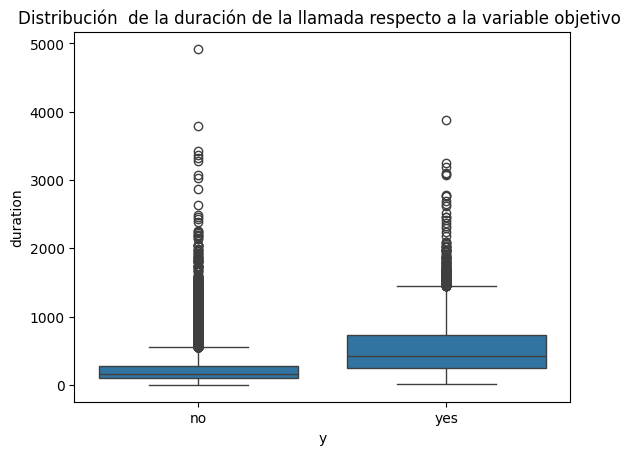

In [23]:
# duration vs y
plt.figure()
plt.title("Distribución  de la duración de la llamada respecto a la variable objetivo ")
sns.boxplot(x='y', y='duration', data=datos1)
plt.show()

Se evidencia que la duración de la llamada es un factor relevante para describir o predecir la variable objetivo, aunque debe recordarse que no se usará en el modelo. Se debe saber si una persona susucribirá el depósito a largo plazo antes de preguntarle, además téngase en cuenta que cómo esta variable esta visiblemente relacionada con 'y' tendrá una influencia positiva en el rendimiento de un modelo, pero esta será "artificial"

# A tener en cuenta: Factores y desiciones de calidad de datos

In [24]:
datos.select("y").distinct().show()

+---+
|  y|
+---+
| no|
|yes|
+---+



## 1. Cambio de valores en y (Compra o no compra)

In [25]:

from pyspark.sql.functions import when, col
# Se requiere cambiar "yes" a 1 en la variable objetivo
datos= datos.withColumn(
    "y",
    when(col("y") == "yes", 1).otherwise(0)
)




In [26]:
datos.select("y").distinct().show()

+---+
|  y|
+---+
|  1|
|  0|
+---+



## 2. Variables que generan sesgo.

### Default

Esta variable tiene el 98% de datos en un solo valor. Al hacer un modelo, la mayoriía de registros con los que el modelo será entrenado serán de personas que son cumplidas, por lo tanto la respuesta del modelo se aproximará únicamente a las personas que si pagan.

In [27]:
datos = datos.drop("default")
categoricas.remove("default")

### Pdays
El 81% de las personas no han sido contactadas, se descartará esta variable, teniendo en cuenta también su correlación numérica con 'previous' (0.48).

In [28]:
datos = datos.drop("pdays")
numericas.remove("pdays")

### Duration

Recuérdese que esta variable sera eliminada porque la intención es conocer si un cliente del banco suscribirá un deposito, para lo cual se desea predecir esto antes de preguntarle por llamada.

In [29]:

datos = datos.drop("duration")
numericas.remove("duration")

## 3. Verificar valores nulos

In [30]:
from pyspark.sql.functions import col, isnan, when, count

datos.select([
    count(
        when(isnan(col(c)) | col(c).isNull(), c)
    ).alias(c)
    for c in datos.columns
]).show()

[Stage 176:============================>                            (1 + 1) / 2]

+---+---+-------+---------+-------+-------+----+-------+---+-----+--------+--------+--------+---+
|age|job|marital|education|balance|housing|loan|contact|day|month|campaign|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+----+-------+---+-----+--------+--------+--------+---+
|  0|  0|      0|        0|      0|      0|   0|      0|  0|    0|       0|       0|       0|  0|
+---+---+-------+---------+-------+-------+----+-------+---+-----+--------+--------+--------+---+



## 4. Balanceo de clases

In [31]:
# Se desea evitar el sesgo de modelo respecto a la variable objetivo
dfMayorDependiente =datos.filter(datos['y']==0)
cantMayor=dfMayorDependiente.count()
dfMenorDependiente =datos.filter(datos['y']==1)
dfOverSampledMinor=dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(),seed=42)
datos=dfMayorDependiente.union(dfOverSampledMinor)
# Se realizará remuestreo con reemplazo del valor minoritario de la variable 'y' para obtener aproximado 50 50


In [32]:
datos.select("y").distinct().show()

+---+
|  y|
+---+
|  0|
|  1|
+---+



# Modelos de aprendizaje de maquina: ¿Comprará el cliente un deposito?

In [33]:
#Partición de conjunto de datos y Conversión de las variables categoricas a numeros. (Se requiere para spark assemnbler)
categoricas.remove("y")
etapas=[]
for col in categoricas:
    indexer=StringIndexer(inputCol=col,outputCol=col + 'x')
    encoder=OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[col+ '_oneHot'])
    etapas += [indexer, encoder]
etiqueta= StringIndexer(inputCol='y',outputCol='label',stringOrderType='alphabetAsc')
etapas+=[etiqueta]

####### NUMERICAS - - - - - -  -


entradaEnsamble=[c+'_oneHot' for c in categoricas]+numericas

- ¿Para que se requiere el VectorAssembler?
  Los modelos implementados en la libreria MLlib de Spark, requieren de una entrada vectorial. Es decir que se requiere una columna con varios vectores como la representación del conjunto de datos, a diferencia de liberias tradicionales como sklearn. VectorAssembler es un transformador que permite agrupar las columnas del conjunto de datos en vectores contenidos en una sola columna.
- ¿y el pipeline?
  Como los procesos de aprendizaje de máquina pueden ser repetitivos en el sentido de la preparación de los datos, se usa el pipeline para simplificar el flujo de trabajo. En este caso se usará para la conversión de características a numeros, luego para binarizar en vectores. Como se pudo apreciar, se usa este pipeline para la etiqueta (y) y se podrá ver que estos pasos se aplican al conjunto de datos entero.

In [34]:
# Creacion del vector assembler necesario para usar modelos en spark.


ensamblador= VectorAssembler(inputCols = entradaEnsamble , outputCol="features")
etapas+= [ensamblador]


In [35]:
#uso de los pasos para crear el pipeline y aplicar estos al conjunto  de datos
etapas
pipeline=Pipeline(stages=etapas)
pipelineModel=pipeline.fit(datos)
pipelineModel.write().overwrite().save('/Almacen/WorkerJulian/') # ups
modelo=pipelineModel.transform(datos)

In [36]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: integer (nullable = false)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- housingx: double (nullable = false)
 |-- housing_oneHot: vector (nullable = true)
 |-- loanx: double (nullable = false)
 |-- loan_oneHot: vector (nullable = true)
 |-- contactx: double (nullable = f

Se requiere separar los datos en predictores y var.objetivo con el fin de realizar modelos de aprendizaje de maquina.

In [37]:
datos1=modelo.select("label","features")
datos1.first()


26/05/24 10:46:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Row(label=0.0, features=SparseVector(39, {0: 1.0, 11: 1.0, 14: 1.0, 17: 1.0, 19: 1.0, 20: 1.0, 31: 1.0, 34: 58.0, 35: 2143.0, 36: 5.0, 37: 1.0}))

In [38]:

datos1.write.mode("overwrite").parquet("output.parquet")
datos2=sparkGaitan.read.parquet("output.parquet")
datos1.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(39,[0,11,14,17,1...|
|  0.0|(39,[2,12,13,17,1...|
+-----+--------------------+
only showing top 2 rows



## Definición de los modelos

In [39]:
# Particion 80 20
trainData, testData = datos2.randomSplit([.8,.2],seed=42)

distroTrain=trainData.groupBy("label").count()

distroTrain=distroTrain.withColumn("porcentaje",distroTrain["count"]*100/trainData.count())
distroTrain.show()
#aproximado 50 50 #


+-----+-----+-----------------+
|label|count|       porcentaje|
+-----+-----+-----------------+
|  1.0|32321|50.26906806022148|
|  0.0|31975|49.73093193977852|
+-----+-----+-----------------+



Existe balance apropiado de clases, aproximado 50 50

In [40]:
distroTest=testData.groupBy("label").count()

distroTest=distroTest.withColumn("porcentaje",distroTest["count"]*100/testData.count())
distroTest.show()

+-----+-----+-----------------+
|label|count|       porcentaje|
+-----+-----+-----------------+
|  1.0| 7949|50.00629089079013|
|  0.0| 7947|49.99370910920987|
+-----+-----+-----------------+



Se observa distribucioon muy similar de procentajes en el conjunto de prueba 

In [41]:
#defincion de la funcion que permite pintar la matriz de confusión de forma totalmente legible e intuitiva
def plotConfusionMat(confMatrix, subtitulo):
    confMatrixPandas = confMatrix.toPandas()
    confMatrixPivote= confMatrixPandas.pivot(index="label",columns="prediction",values="count").fillna(0)
    plt.figure(figsize=(8,6))
    sns.heatmap(confMatrixPivote ,annot=True,fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de confusión')
    plt.xlabel('label prediction')
    plt.ylabel('Label')
    plt.show()

def plotROC(predictions, rocMetric, subtitulo):

    ###### Calculo de las probabilidades y las respectivas proporciones
    if 'probability' in predictions.columns:
        probs=predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    else:
            # SVM: rawPrediction es un Vector([neg_score, pos_score])
            # Se toma el segundo elemento (clase positiva)
        probs = predictions.select('rawPrediction') \
                    .rdd.map(lambda row: float(row['rawPrediction'][1]))
    labels =predictions.select('label').rdd.map(lambda row: row['label'])
    fpr,tpr, thresholds =roc_curve(labels.collect(),probs.collect())



    ####### - - - - - - - - - - - - - - - - - - - - - - - - - - -
    plt.figure(figsize=(8,6))
    plt.plot(fpr,tpr,color="blue",lw=2, label=f'ROC curve {rocMetric}')
    plt.plot([0,1],[0,1],color='red', lw=2, linestyle='--')
    plt.xlabel('Prop falsos positivos')
    plt.ylabel('prop verdaderos positivos')
    plt.title('Curva roc')
    plt.suptitle(':)')
    plt.legend(loc='lower right')
    plt.show()        
    

## Primer modelo : Regresión logistica

In [42]:
from pyspark.ml.classification import LogisticRegression
instanciaLR=LogisticRegression(featuresCol='features',labelCol='label',maxIter=10)
modeloLR= instanciaLR.fit(trainData)


26/05/24 10:47:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [43]:
## Observar algunas probabilidades calculadadas por el modelo
predLR=modeloLR.transform(testData)
predLR.select("label","prediction","probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.51717236104099...|
|  0.0|       0.0|[0.57940308574806...|
|  0.0|       0.0|[0.5357349410532,...|
|  0.0|       0.0|[0.64752458034008...|
|  0.0|       0.0|[0.55949119493618...|
+-----+----------+--------------------+
only showing top 5 rows



In [44]:
## se crea la instancia del evalulador
evaluadorLR= MulticlassClassificationEvaluator(labelCol="label",predictionCol="prediction")

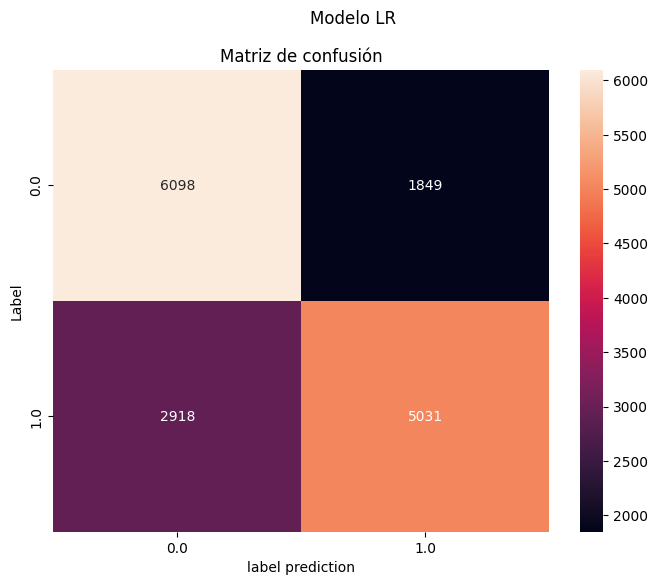

acc  0.7001132360342225
prec  0.7038050284787007
recall   0.7001132360342225
f1   0.6987534051668185


In [45]:
primerModelo="Modelo LR"
confMatrixLR =predLR.groupBy("label","prediction").count()
plotConfusionMat(confMatrixLR,primerModelo)
accuracyLR=evaluadorLR.evaluate(predLR , {evaluadorLR.metricName:"accuracy"})
precisionLR=evaluadorLR.evaluate(predLR , {evaluadorLR.metricName:"weightedPrecision"})
recallLR=evaluadorLR.evaluate(predLR , {evaluadorLR.metricName:"weightedRecall"})
f1LR=LR=evaluadorLR.evaluate(predLR , {evaluadorLR.metricName:"f1"})
print("acc ",accuracyLR)
print("prec ",precisionLR)
print("recall  ",recallLR)
print("f1  ",f1LR)


- Se observa que este primer modelo hace bien la tarea de separar ambas clases, se observa que la asertividadd general es de 0.70 (accuracy), lo que muestra que el modelo hace perdicciones correctas de cualquier clase en un 70% de los casos en promedio.


Veamos la curva roc a continuación.

0.7684787835905514
areaUnderROC


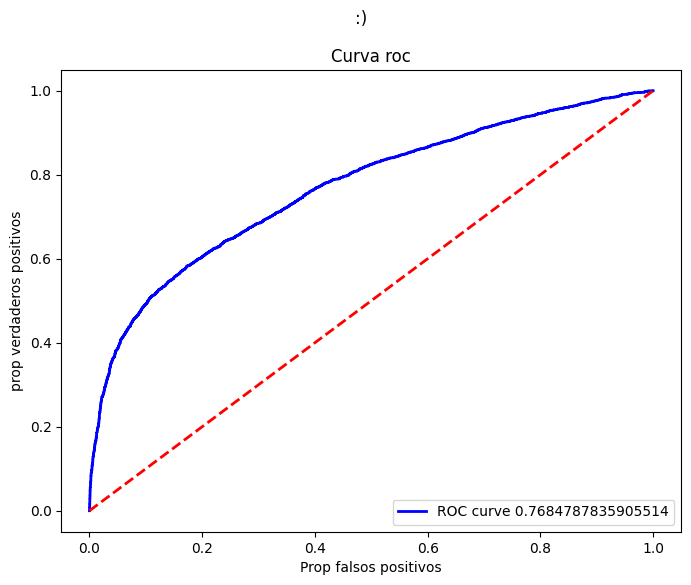

In [46]:
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR,primerModelo)

- El area bajo la curva ROC (AUC) es de 0.76, tanto visualmente como numéricamente se aprecia que el modelo es mejor que el azar (linea recta diagonal), este es un buen modelo, sin embargo se espera lograr mejoras signficativas con los demás modelos y realizar comparación de resultados:

## Segundo Modelo: Decision Tree


In [47]:
from pyspark.ml.classification import DecisionTreeClassifier
segundoModelo = "Modelo DT"
instanciaDT = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloDT = instanciaDT.fit(trainData)

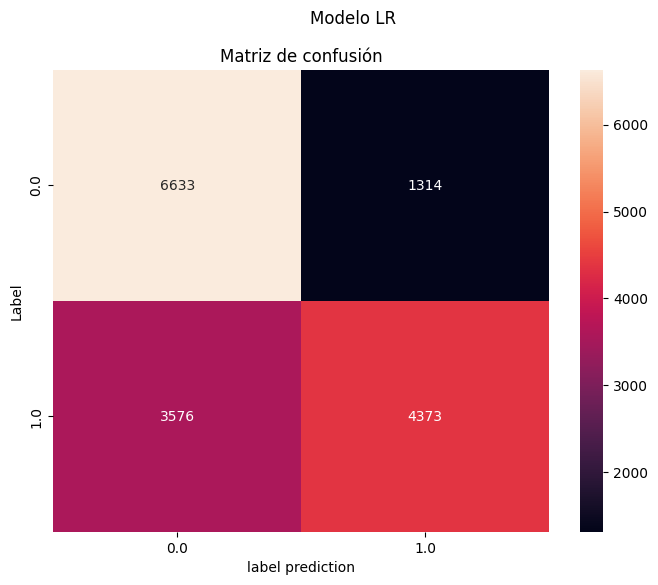

acc  0.6923754403623553
prec  0.709341277944566
recall   0.6923754403623553
f1   0.6860233761726394


In [48]:
predDT=modeloDT.transform(testData)
## se crea la instancia del evalulador
evaluadorDT=MulticlassClassificationEvaluator(labelCol="label",predictionCol="prediction")


confMatrixDT =predDT.groupBy("label","prediction").count()
plotConfusionMat(confMatrixDT,primerModelo)
accuracyDT=evaluadorDT.evaluate(predDT, {evaluadorDT.metricName:"accuracy"})
precisionDT=evaluadorDT.evaluate(predDT , {evaluadorDT.metricName:"weightedPrecision"})
recallDT=evaluadorDT.evaluate(predDT , {evaluadorDT.metricName:"weightedRecall"})
f1DT=evaluadorDT.evaluate(predDT , {evaluadorDT.metricName:"f1"})
print("acc ",accuracyDT)
print("prec ",precisionDT)
print("recall  ",recallDT)
print("f1  ",f1DT)


- Se observa que las métricas de rendimiento disminuyen ligeramente, recordemos que, aunque en este caso se logró un desempeño aceptable, los arboles por sí solos se consideran pobres en aprender patrones complejos. Existe aumento de los falsos negativos para esta matriz de confusión, es decir que se están escapando clientes que si comprarian el deposito pero que el modelo dice que no comprarian el deposito, por ello se puede decir que se ha obtenido un peor modelo.

Para que los arboles tengan un mayor poder predictivo, se suelen usar ensambles, que combinan las "reglas" que hacen los distintos arboles para aumentar el rendimiento. Véase como surge la curva ROC:

0.7684827806966149
areaUnderROC


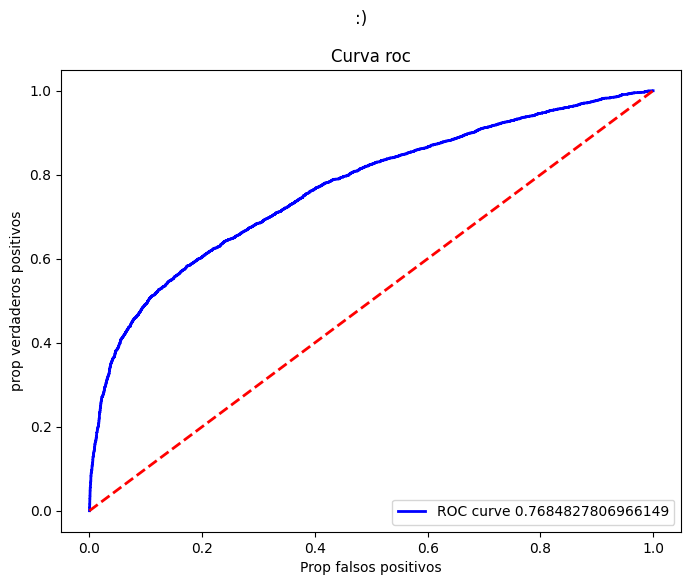

In [49]:
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predLR)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predLR,rocDT,primerModelo)

- El AUC es muy similar que el modelo anterior, no obstante, en este modelo bajo la cantidad de falsos positivos y subio la cantidad de falsos negativo. Este modelo deja escapar más clientes buenos que el anterior, como este es un factor crítico se puede decir que el modelo de regresión logística lo ha hecho mejor a pesar de métricas muy similares

## Tercer modelo: Random Forest Classifier


In [50]:
from pyspark.ml.classification import RandomForestClassifier

tercerModelo = "Modelo RF"

instanciaRF = RandomForestClassifier(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloRF = instanciaRF.fit(trainData)

predRF = modeloRF.transform(testData)





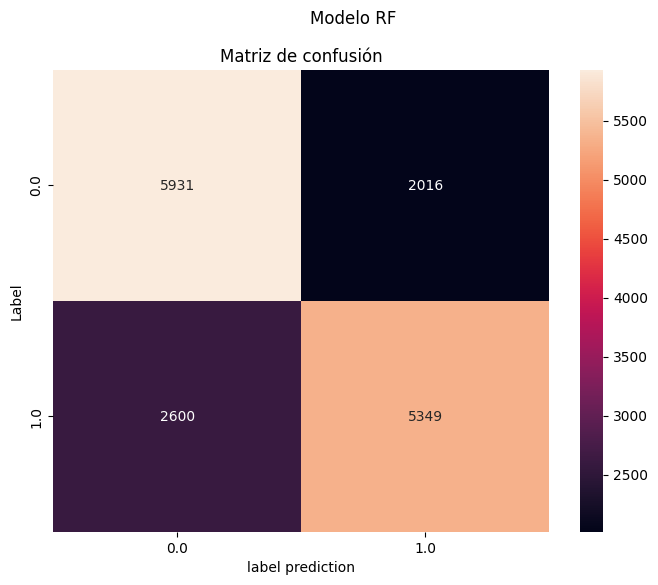

acc  0.7096124811273277
prec  0.7107529912524053
recall   0.7096124811273277
f1   0.709221351569935


In [51]:
## se crea la instancia del evalulador
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")


confMatrixRF = predRF.groupBy("label","prediction").count()

plotConfusionMat(confMatrixRF, tercerModelo)

accuracyRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName:"accuracy"})
precisionRF = evaluadorRF.evaluate(predRF , {evaluadorRF.metricName:"weightedPrecision"})
recallRF = evaluadorRF.evaluate(predRF , {evaluadorRF.metricName:"weightedRecall"})
f1RF = evaluadorRF.evaluate(predRF , {evaluadorRF.metricName:"f1"})

print("acc ", accuracyRF)
print("prec ", precisionRF)
print("recall  ", recallRF)
print("f1  ", f1RF)



- Se observa aumento de las métricas en aproximadamente 0.1 y valores similares de falsos negativos y positivos en la matriz de confusión respecto al modelo de regresión logística.

Véase la curva ROC.

0.775547281783456
areaUnderROC


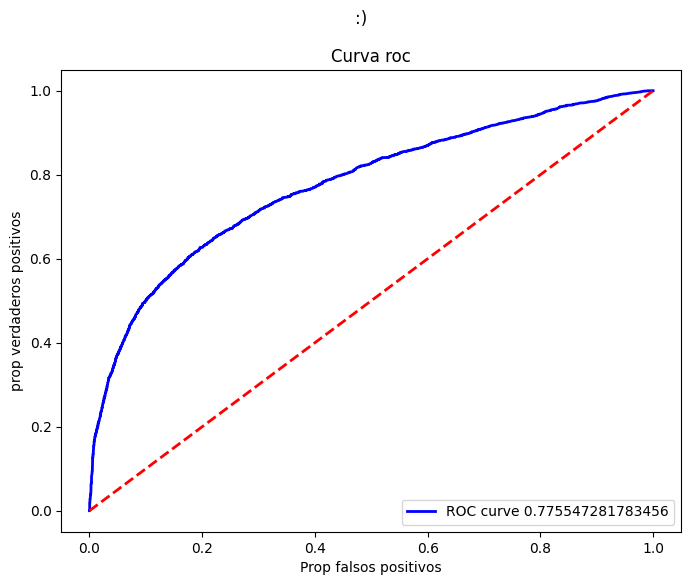

In [52]:
# Se calcula y se presenta la gráfica ROC con predicciones
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF = evaluadorBinRF.evaluate(predRF)

print(rocRF)
print(evaluadorBinRF.getMetricName())

plotROC(predRF, rocRF, tercerModelo)

- Existe un aumento del área sobre la curva casi nulo, es decir, aunque este modelo es mejor que el arbol de desición, es aproximadamente igual de bueno que el de regresión logística.

## Cuarto Modelo: Gradient Boosted Tree


In [53]:
from pyspark.ml.classification import GBTClassifier

cuartoModelo = "Modelo GBT"

instanciaGBT = GBTClassifier(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloGBT = instanciaGBT.fit(trainData)

predGBT = modeloGBT.transform(testData)



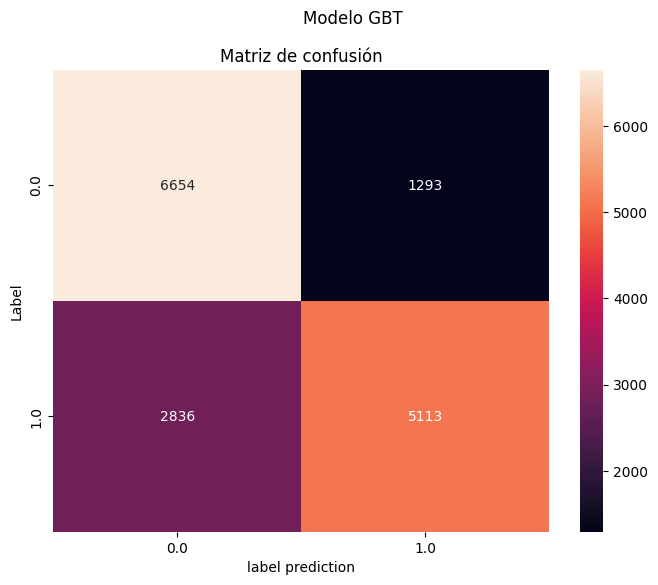

acc  0.7402491192752894
prec  0.7496646479696807
recall   0.7402491192752894
f1   0.7377816563883774


In [54]:
## se crea la instancia del evalulador
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")


confMatrixGBT = predGBT.groupBy("label","prediction").count()

plotConfusionMat(confMatrixGBT, cuartoModelo)

accuracyGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName:"accuracy"})
precisionGBT = evaluadorGBT.evaluate(predGBT , {evaluadorGBT.metricName:"weightedPrecision"})
recallGBT = evaluadorGBT.evaluate(predGBT , {evaluadorGBT.metricName:"weightedRecall"})
f1GBT = evaluadorGBT.evaluate(predGBT , {evaluadorGBT.metricName:"f1"})

print("acc ", accuracyGBT)
print("prec ", precisionGBT)
print("recall  ", recallGBT)
print("f1  ", f1GBT)



- Se observa mejora de 0.3 aproximadamente en las métricas respecto al modelo de regresión logística, se observa que la cantidad de falsos positivos y falsos negaticos disminuye significativamente, por lo que necesariamente aumentan los aciertos en este modelo.

Véase la curva ROC:

0.8116277889134779
areaUnderROC


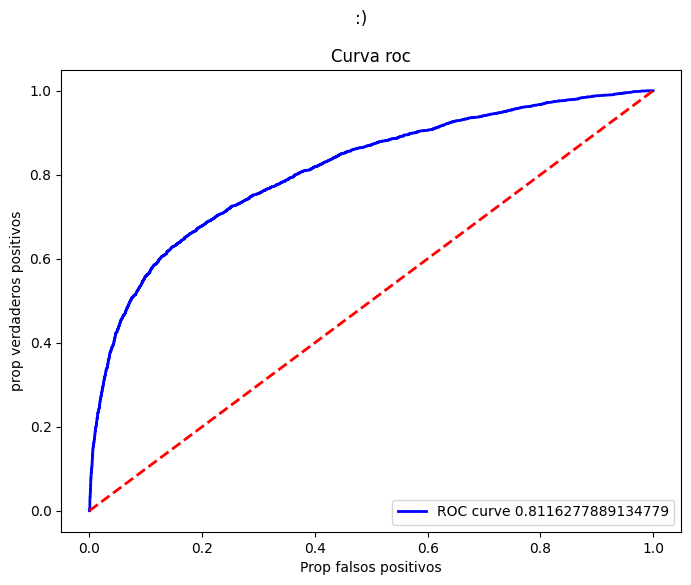

In [55]:
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocGBT = evaluadorBinGBT.evaluate(predGBT)

print(rocGBT)
print(evaluadorBinGBT.getMetricName())

plotROC(predGBT, rocGBT, cuartoModelo)

- Se observa una buena mejora el valor AUC, pues se tiene que se ha superado el umbral de 0.8 y se ha aumentado este valor en aproximadamente 0.3 con respecto al modelo de regresión logística. Lo cual es un avance significativo.

## Quinto Modelo: Support Vector Machine 


In [56]:
from pyspark.ml.classification import LinearSVC

quintoModelo = "Modelo SVM"

instanciaSVM = LinearSVC(labelCol='label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloSVM = instanciaSVM.fit(trainData)

predSVM = modeloSVM.transform(testData)



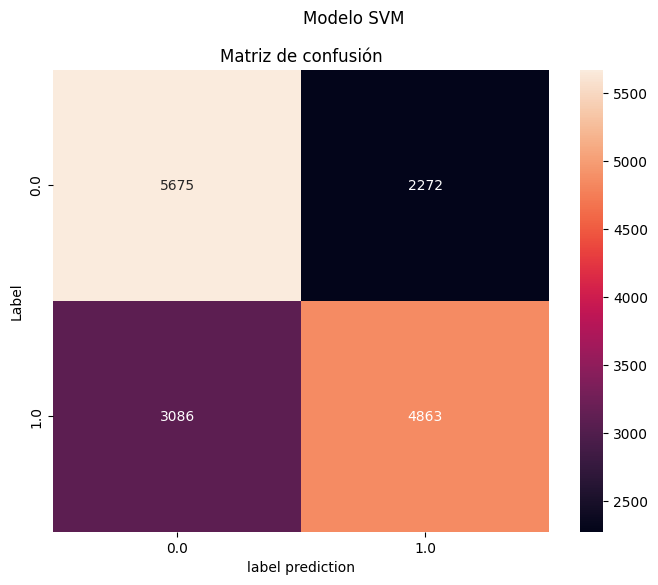

acc  0.6629340714645193
prec  0.6646655431414019
recall   0.6629340714645193
f1   0.662050067324412


In [57]:
## se crea la instancia del evalulador
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")


confMatrixSVM = predSVM.groupBy("label","prediction").count()

plotConfusionMat(confMatrixSVM, quintoModelo)

accuracySVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName:"accuracy"})
precisionSVM = evaluadorSVM.evaluate(predSVM , {evaluadorSVM.metricName:"weightedPrecision"})
recallSVM = evaluadorSVM.evaluate(predSVM , {evaluadorSVM.metricName:"weightedRecall"})
f1SVM = evaluadorSVM.evaluate(predSVM , {evaluadorSVM.metricName:"f1"})

print("acc ", accuracySVM)
print("prec ", precisionSVM)
print("recall  ", recallSVM)
print("f1  ", f1SVM)


- Este es el peor modelo de los que se ha evaluado, tiene aumento de los falsos positicos y falsos negativos, de manera tal que las métricas de rendimiento disminuyen considerablemente, véase el AUC

0.7507273189598667
areaUnderROC


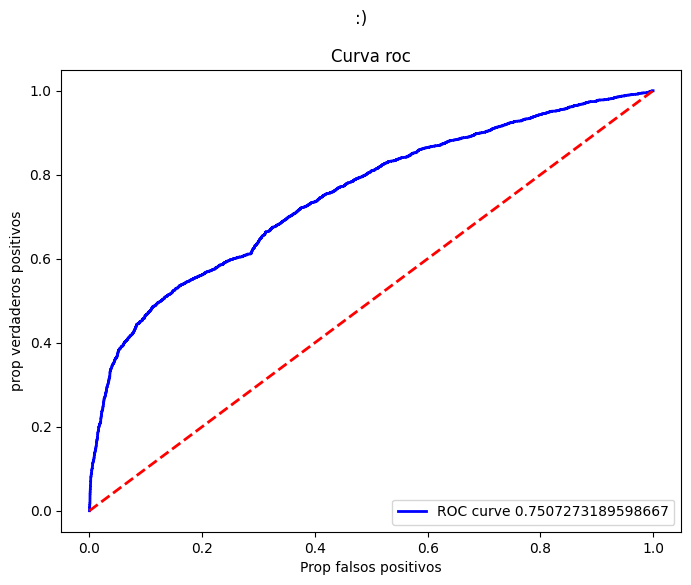

In [58]:

evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocSVM = evaluadorBinSVM.evaluate(predSVM)

print(rocSVM)
print(evaluadorBinSVM.getMetricName())

plotROC(predSVM, rocSVM, quintoModelo)

- Existe disminución de 0.2 respecto al valor AUC del modelo de regresión logística, además, con esta métrica se ratifica que este modelo fue el que peor modelo tuvo.

## Comparación de los resultados obtenidos y conclusiones


Se pinta una tabla comparativa entre las métricas de rendimiento de los modelos realizados, se declara que se ha usado IA para generar esta tabla.

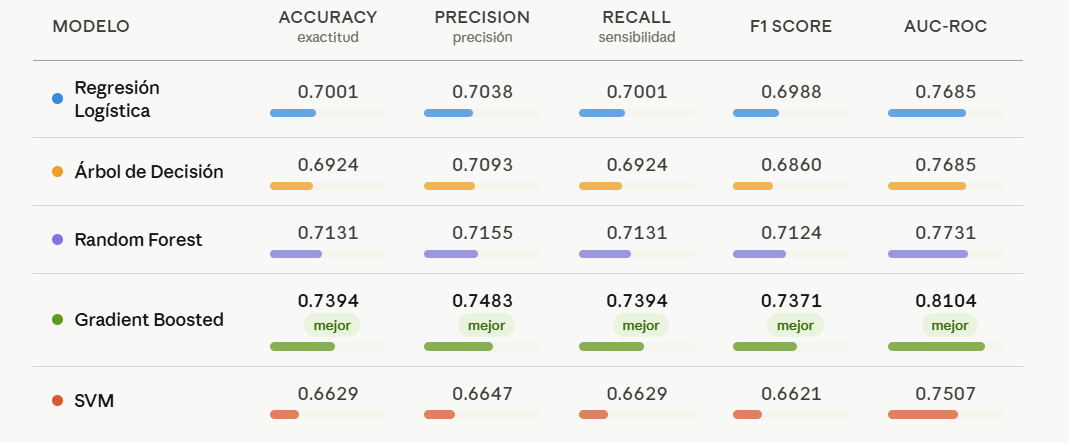

### Se puede afirmar que:

- El mejor modelo fue el de Gradient Boosted Tree, todas las métricas fueron superiores a las demás, además el AUC mayor a 0.8 se considera bueno.
- El peor modelo fue el de SVM, tuvo las peores métricas en todos los aspectos
- Aunque el peor modelo fue el de SVM, no se puede decir que sea totalmente obsoleto, pues su AUC sigue estando por encima de 0.5 por más de 2 decimas, por lo cual es seguro que el modelo predice mejor que lo que sería una moneda al aire.
- En ese orden de ideas, hubo mejores modelos que otros pero ninguno es totalmente obsoleto

# Conclusiones generales.

- La implementación de modelos de aprendizaje de máquina no es de un sólo paso. Requiere de un conocimiento previo y profundo de los datos.
- El análisis exploratorio realizado permitio comprender la relaciónes clave entre variables, que pudieran potenciar o limitar el rendimiento de un modelo de aprendizaje de máquina.
- Se obtuvo éxito al crear modelos de predicción sobre si un cliente suscribirá un depósito a largo plazo, todos los modelos realizados fueron buenos teniendo en cuenta que son mejor que el azar.
- Las transformaciones al conjunto de datos necesarias son clave, pues permiten mejorar los rendimientos de los modelos o bien permiten que el modelo cumpla su proposito de predicción sin sesgos; Por ejemplo, en este caso no se hizo uso de duration, es una variable con alto poder predictivo, pero cuando la llamada dura demasiado, es prácticamente seguro que el cliente ha adiquirido el deposito, por lo cual incluir esta variable es similar a dar la respuesta al modelo en el conjunto de prueba prácticamente, obteniendo buenas métricas de forma falsa, pues se requiere saber si el cliente suscribirá el depósito ántes de preguntarle.

In [60]:
sparkGaitan.stop()